In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier,  HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
import warnings 
import missingno as msno
import scipy.stats as stats
from scipy.stats import chi2_contingency
import keras
from keras.models import Sequential
from keras.models import Model
from keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')
# 0) Imports
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate




2025-04-25 16:42:58.018933: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-25 16:42:58.021105: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 16:42:58.025079: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 16:42:58.035499: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745599378.052631 3437095 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745599378.05

In [2]:
features = pd.read_csv('train_values.csv')
labels = pd.read_csv('train_labels.csv')

df = pd.concat([features, labels['damage_grade']], axis=1)
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [3]:
# duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# if >0, optionally drop them:
df = df.drop_duplicates()

# look for impossible values, e.g. negative counts
print(df[df['count_families'] < 0])


Duplicate rows: 0
Empty DataFrame
Columns: [building_id, geo_level_1_id, geo_level_2_id, geo_level_3_id, count_floors_pre_eq, age, area_percentage, height_percentage, land_surface_condition, foundation_type, roof_type, ground_floor_type, other_floor_type, position, plan_configuration, has_superstructure_adobe_mud, has_superstructure_mud_mortar_stone, has_superstructure_stone_flag, has_superstructure_cement_mortar_stone, has_superstructure_mud_mortar_brick, has_superstructure_cement_mortar_brick, has_superstructure_timber, has_superstructure_bamboo, has_superstructure_rc_non_engineered, has_superstructure_rc_engineered, has_superstructure_other, legal_ownership_status, count_families, has_secondary_use, has_secondary_use_agriculture, has_secondary_use_hotel, has_secondary_use_rental, has_secondary_use_institution, has_secondary_use_school, has_secondary_use_industry, has_secondary_use_health_post, has_secondary_use_gov_office, has_secondary_use_use_police, has_secondary_use_other, damag

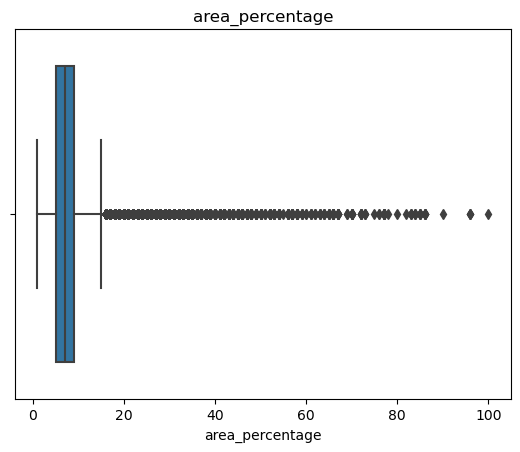

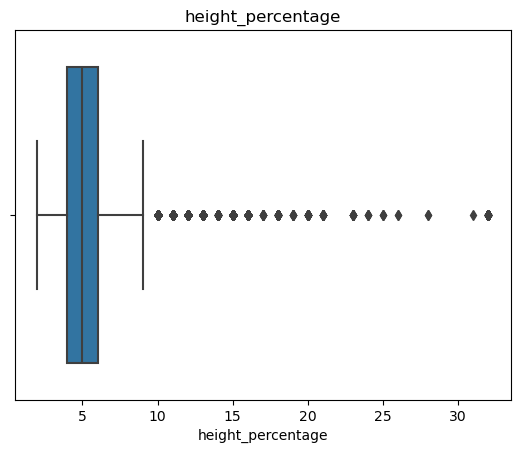

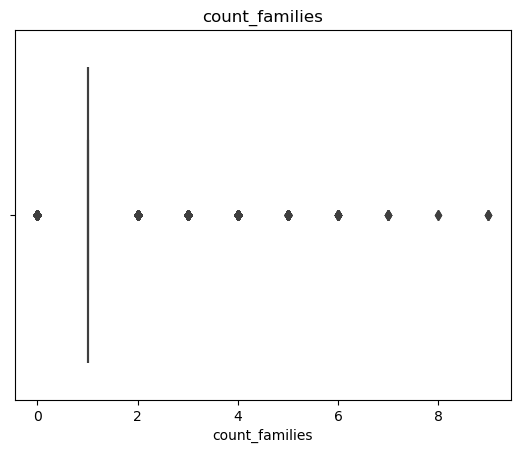

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# boxplot on key numeric features
for col in ['area_percentage','height_percentage','count_families']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [5]:
print(df['area_percentage'].describe())
print(df['height_percentage'].describe())
# Optional: list the top 10 rows
print(df.sort_values('area_percentage', ascending=False).head(10))


count    260601.000000
mean          8.018051
std           4.392231
min           1.000000
25%           5.000000
50%           7.000000
75%           9.000000
max         100.000000
Name: area_percentage, dtype: float64
count    260601.000000
mean          5.434365
std           1.918418
min           2.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          32.000000
Name: height_percentage, dtype: float64
        building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
4790         361707               3             175            6924   
127007       220534               6            1082           11745   
200707      1021705              26              39            9897   
204527       661586               7              49            7507   
149199       764043              21             929             917   
56752        645420              26              39            9897   
161256       392807              26             886      

In [6]:
#categorical
for col in df.select_dtypes('object'):
    print(col, df[col].value_counts())

land_surface_condition land_surface_condition
t    216757
n     35528
o      8316
Name: count, dtype: int64
foundation_type foundation_type
r    219196
w     15118
u     14260
i     10579
h      1448
Name: count, dtype: int64
roof_type roof_type
n    182842
q     61576
x     16183
Name: count, dtype: int64
ground_floor_type ground_floor_type
f    209619
x     24877
v     24593
z      1004
m       508
Name: count, dtype: int64
other_floor_type other_floor_type
q    165282
x     43448
j     39843
s     12028
Name: count, dtype: int64
position position
s    202090
t     42896
j     13282
o      2333
Name: count, dtype: int64
plan_configuration plan_configuration
d    250072
q      5692
u      3649
s       346
c       325
a       252
o       159
m        46
n        38
f        22
Name: count, dtype: int64
legal_ownership_status legal_ownership_status
v    250939
a      5512
w      2677
r      1473
Name: count, dtype: int64


In [7]:
# count missing per column
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

# percent missing
percent_missing = 100 * missing / len(df)
print(percent_missing[percent_missing > 0])

Series([], dtype: int64)
Series([], dtype: float64)


In [8]:
print(df.isnull().sum())

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

In [9]:
#Splitting the data between training and testing
X_train, X_val, y_train, y_val = train_test_split(df.drop('damage_grade', axis=1), df['damage_grade'], random_state=20, shuffle=True, test_size=0.01)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(257994, 39)
(2607, 39)
(257994,)
(2607,)


In [10]:
column_names = list(df.drop('damage_grade', axis=1).columns)
multi_class_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()>2]
binary_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()==2]
num_columns = [col for col in column_names if df[col].dtype!='object']
print(f"Multi Class columns: {multi_class_columns}")
print(f"Binary columns: {binary_columns}")
print(f"Numerical columns: {num_columns}")

Multi Class columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Binary columns: []
Numerical columns: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', '

In [11]:
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    # get the cutoffs once
    qs = X[['area_percentage','height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    
    # clip each column
    for col in ['area_percentage','height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

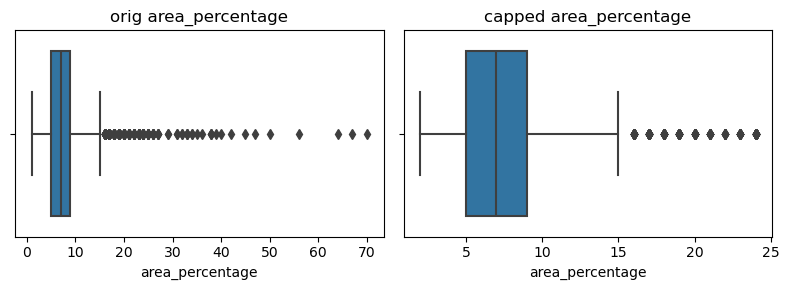

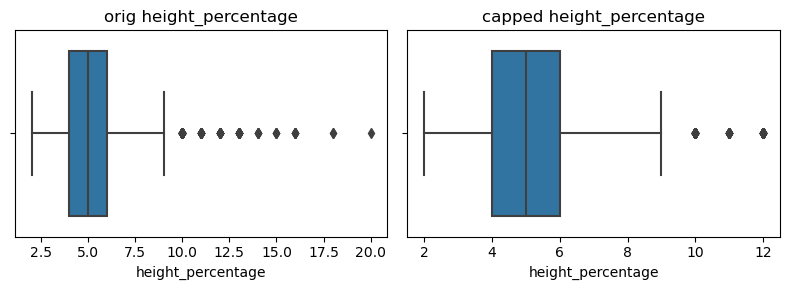

In [12]:
# apply to a small sample
sample = df[['area_percentage','height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)

import matplotlib.pyplot as plt, seaborn as sns

for col in ['area_percentage','height_percentage']:
    fig, axes = plt.subplots(1,2, figsize=(8,3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"orig {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"capped {col}")
    plt.tight_layout()
    plt.show()


In [13]:
models = [
    RandomForestClassifier(random_state=42),
]

In [14]:

# 1) Define our custom capper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols            # e.g. ['area_percentage','height_percentage']
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # X is a numpy array of shape (n_samples, n_num_cols)
        # find each target col’s integer index
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        # extract the sub‐array of just those columns
        sub = X[:, self.col_indices_]
        # compute quantiles along axis=0 → shape (2, len(cols))
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        # clip each specified column by its learned lo_/hi_
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

In [15]:
# 2) Numeric pipeline
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('cap',    OutlierCapper(cols=['area_percentage','height_percentage'],
                             lower=0.01, upper=0.99)),
    ('power',  PowerTransformer(method='yeo-johnson')),
    ('scale',  RobustScaler()),
])


In [16]:
# 3) Categorical pipeline
cat_pipeline = Pipeline([
    # 3a) Impute missing categories into a "MISSING" bucket
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),
    # 3b) One-hot encode all levels, ignore unseen at predict time
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [17]:
# 4) Assemble ColumnTransformer
preprocessor = ColumnTransformer([
    # apply numeric_pipeline to all numeric features
    ('num', numeric_pipeline, num_columns),
    # apply cat_pipeline to all categorical features
    ('cat', cat_pipeline,   multi_class_columns + binary_columns),
])


In [18]:
# 5) Pipeline factory
def get_pipeline(model):
    """
    Returns a full Pipeline that:
     - applies preprocessor to DataFrame
     - then fits the model
    """
    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf',        model)
    ])

In [19]:
# 7) Quick Stratified 3-fold CV to compare
cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

In [20]:
import numpy as np
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline

def train_robust_decision_tree(
    X, y,
    preprocessor,
    scoring=None,             # expects a dict of metrics
    outer_cv_splits=5,
    inner_cv_splits=3,
    n_iter=50,
    random_state=42
):
    """
    Nested‐CV hyperparameter tuning of a DecisionTreeClassifier,
    returning both accuracy and weighted_f1 outer‐fold scores,
    and refitting the best model on weighted_f1.
    """
    # Default two‐metric dict if none provided
    if scoring is None:
        scoring = {
            'accuracy':    'accuracy',
            'weighted_f1': 'f1_weighted'
        }

    # 1) Define classifier + search space
    tree = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=random_state
    )
    param_dist = {
        'clf__criterion':         ['gini', 'entropy'],
        'clf__max_depth':         [None] + list(range(3, 21)),
        'clf__min_samples_split': randint(2, 20),
        'clf__min_samples_leaf':  randint(1, 20),
        'clf__max_features':      [None, 'sqrt', 'log2'],
        'clf__ccp_alpha':         np.logspace(-4, -1, 20)
    }

    # 2) Pipeline
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', tree)
    ])

    # 3) Inner RandomizedSearchCV (refit on weighted_f1)
    inner_cv = StratifiedKFold(
        n_splits=inner_cv_splits,
        shuffle=True,
        random_state=random_state
    )
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=inner_cv,
        scoring=scoring,
        refit='weighted_f1',      # <--- pick your primary metric here
        random_state=random_state,
        verbose=1,
        n_jobs=-1
    )

    # 4) Outer CV for unbiased performance estimates
    outer_cv = StratifiedKFold(
        n_splits=outer_cv_splits,
        shuffle=True,
        random_state=random_state
    )
    outer_scores = cross_validate(
        search, X, y,
        cv=outer_cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    # 5) Final fit on full data (uses weighted_f1 to pick best)
    search.fit(X, y)
    best_model = search.best_estimator_

    # 6) Collect both outer‐fold metrics
    outer_test_scores = {
        metric: outer_scores[f'test_{metric}']
        for metric in scoring
    }

    return best_model, {
        'outer_test_scores': outer_test_scores,
        'inner_search': search
    }


In [21]:
# 1) Define your two‐metric scoring dict
scoring = {
    'accuracy':    'accuracy',
    'weighted_f1': 'f1_weighted'
}

# 2) Train
best_dt, results = train_robust_decision_tree(
    X_train, y_train,
    preprocessor=preprocessor,
    scoring=scoring,
    outer_cv_splits=5,
    inner_cv_splits=3,
    n_iter=15,
    random_state=42
)

# 3) Inspect outer‐fold metrics
acc_scores = results['outer_test_scores']['accuracy']
f1_scores  = results['outer_test_scores']['weighted_f1']

print("Outer CV accuracy:   ", acc_scores)
print("Mean accuracy:       ", np.mean(acc_scores))
print("Outer CV weighted F1:", f1_scores)
print("Mean weighted F1:    ", np.mean(f1_scores))

# 4) Best hyperparameters (by weighted_f1)
print("\nBest hyperparameters found:")
for k, v in results['inner_search'].best_params_.items():
    print(f"  • {k} = {v}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Outer CV accuracy:    [0.60088374 0.61038005 0.60698851 0.60654276 0.60285282]
Mean accuracy:        0.605529575584115
Outer CV weighted F1: [0.60752228 0.61604205 0.61387207 0.61277462 0.60981539]
Mean weighted F1:     0.6120052828281599

Best hyperparameters found:
  • clf__ccp_alpha = 9.999999999999999e-05
  • clf__criterion = entropy
  • clf__max_depth = 13
  • clf__max_features = None
  • clf__min_samples_leaf = 17
  • clf__min_samples_split = 11


In [22]:
# for model in models:
#     pipe   = get_pipeline(model)
#     cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
#     records.append({
#         'Model':    type(model).__name__,
#         'Accuracy': cv_res['test_accuracy'].mean(),
#         'F1 score': cv_res['test_weighted_f1'].mean()   # <-- use test_weighted_f1
#     })

# results_df = pd.DataFrame(records)
# print("Cross-validation results:")
# print(results_df)

In [23]:
# 3) Examine both metrics
print("Outer CV accuracy scores:   ", results['outer_test_scores']['accuracy'])
print("Mean accuracy:              ", np.mean(results['outer_test_scores']['accuracy']))
print("Outer CV weighted F1 scores:", results['outer_test_scores']['weighted_f1'])
print("Mean weighted F1:           ", np.mean(results['outer_test_scores']['weighted_f1']))

# 4) Best hyperparameters
print("\nBest hyperparameters found:")
for k, v in results['inner_search'].best_params_.items():
    print(f"  • {k} = {v}")


Outer CV accuracy scores:    [0.60088374 0.61038005 0.60698851 0.60654276 0.60285282]
Mean accuracy:               0.605529575584115
Outer CV weighted F1 scores: [0.60752228 0.61604205 0.61387207 0.61277462 0.60981539]
Mean weighted F1:            0.6120052828281599

Best hyperparameters found:
  • clf__ccp_alpha = 9.999999999999999e-05
  • clf__criterion = entropy
  • clf__max_depth = 13
  • clf__max_features = None
  • clf__min_samples_leaf = 17
  • clf__min_samples_split = 11


In [24]:
# best_results = []

# for model in models:
#     name = type(model).__name__
#     pipe = get_pipeline(clone(model))

#     # grab the right search space
#     param_dist = param_distributions[name]

#     search = RandomizedSearchCV(
#         estimator=pipe,
#         param_distributions=param_dist,
#         n_iter=30,               # try 30 random combos
#         cv=cv,
#         scoring=scoring,
#         n_jobs=1,                # parallelism inside LGBM is already limited
#         random_state=42,
#         verbose=1
#     )
#     search.fit(X_train, y_train)

#     print(f"=== {name} best ===")
#     print("score:", search.best_score_)
#     print("params:", search.best_params_)

#     best_results.append({
#         'Model': name,
#         'Best Score': search.best_score_,
#         **{k.replace('clf__',''): v for k,v in search.best_params_.items()}
#     })

# best_df = pd.DataFrame(best_results)
# print("\nSummary of best results:\n", best_df)

In [25]:
df_test = pd.read_csv('test_values.csv')

In [26]:
df_test

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,t,r,...,1,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,n,r,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,t,r,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,t,r,...,0,0,0,0,0,0,0,0,0,0


In [27]:
ids     = df_test['building_id'].values
ids

array([ 300051,   99355,  890251, ..., 1049160,  442785,  501372])

In [28]:
X_test  = df_test

In [29]:
# 1) Your fitted pipeline is already in `best_dt`
best_dt_pipe = best_dt

# 2) (Optional) Retrain on the full data
best_dt_pipe.fit(X_train, y_train)

# 3) Make predictions on your hold-out / test set
preds = best_dt_pipe.predict(X_test)

# 4) Build and save the submission
import pandas as pd

submission_df = pd.DataFrame({
    'building_id':  ids,
    'damage_grade': preds
})

submission_df.to_csv('DecisionTree_tuned_submission.csv', index=False)
print("Saved DecisionTree_tuned_submission.csv")


Saved DecisionTree_tuned_submission.csv


In [30]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
y_val_pred = best_dt_pipe.predict(X_val)

# 4) Get the same detailed metrics you wanted before
print("Validation Classification Report:\n")
print(classification_report(y_val, y_val_pred, digits=4))

print("Validation Confusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred))

Validation Classification Report:

              precision    recall  f1-score   support

           1     0.3458    0.8252    0.4874       246
           2     0.7517    0.5060    0.6049      1490
           3     0.6067    0.7084    0.6536       871

    accuracy                         0.6038      2607
   macro avg     0.5681    0.6799    0.5820      2607
weighted avg     0.6650    0.6038    0.6101      2607

Validation Confusion Matrix:

[[203  39   4]
 [340 754 396]
 [ 44 210 617]]
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits


**New approach**

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import (
    RepeatedStratifiedKFold, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV,
    cross_validate, train_test_split
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
import joblib  # for version logging

scoring = {
    'acc':  'accuracy',
    'f1':   'f1_macro',       # or 'f1_weighted', depending on your class balance
    'prec': 'precision_macro',
    'rec':  'recall_macro'
}
random_state=42

tree = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=random_state
    )

base_pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', tree)
    ])
model= base_pipe

# 2) Nested CV: outer = repeat-stratified, inner = stratified
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Hyperparameter search
# 3a) Grid search (like RF)
dt_grid = {
    'clf__criterion':         ['gini', 'entropy'],
    'clf__max_depth':         [None] + list(range(3, 21)),
    'clf__min_samples_split': [2, 5, 10, 20],           # list, not randint
    'clf__min_samples_leaf':  [1, 2, 4, 8],
    'clf__ccp_alpha':         list(np.logspace(-4, -1, 20))
}


grid_search = GridSearchCV(
    model, dt_grid, refit='f1',
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print("Best RF-style params:", grid_search.best_params_)

# 3b) Randomized search (NN-style)
from scipy.stats import uniform, randint
dt_dist = {
        'clf__criterion':         ['gini', 'entropy'],
        'clf__max_depth':         [None] + list(range(3, 21)),
        'clf__min_samples_split': randint(2, 20),
        'clf__min_samples_leaf':  randint(1, 20),
        'clf__max_features':      [None, 'sqrt', 'log2'],
        'clf__ccp_alpha':         np.logspace(-4, -1, 20)
    }


rand_search = RandomizedSearchCV(
    model, dt_dist, refit='f1',
    n_iter=15, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=1
)
rand_search.fit(X_train, y_train)
print("Best NN-style params:", rand_search.best_params_)


#3c) Bayesian hyperparameter search ---
dt_bayes_spaces = {
    'clf__criterion':         Categorical(['gini', 'entropy']),
    'clf__max_depth':         Categorical([None] + list(range(3, 21))),
    'clf__min_samples_split': Integer(2, 20),
    'clf__min_samples_leaf':  Integer(1, 20),
    'clf__max_features':      Categorical([None, 'sqrt', 'log2']),
    'clf__ccp_alpha':         Real(1e-4, 1e-1, prior='log-uniform'),
}

bayes_search = BayesSearchCV(
    estimator=base_pipe,
    search_spaces=dt_bayes_spaces,
    n_iter=15,
    cv=inner_cv,
    refit='f1',
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
bayes_search.fit(X_train, y_train)
print("Best Bayesian params:", bayes_search.best_params_)
best_bayes = bayes_search.best_estimator_

Fitting 5 folds for each of 12160 candidates, totalling 60800 fits


Process LokyProcess-39:
Traceback (most recent call last):
  File "/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py", line 463, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/joblib/parallel.py", line 598, in __call__
    return [func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/joblib/parallel.py", line 598, in <listcomp>
    return [func(*args, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/utils/parallel.py", line 129, in 

KeyboardInterrupt: 

In [ ]:
best_model = rand_search.best_estimator_

In [ ]:
# 5) Calibrated final model on full train
best = rand_search.fit(X_train, y_train).best_estimator_
calibrated = CalibratedClassifierCV(best, cv='prefit', method='isotonic')
calibrated.fit(X_train, y_train)

# 6) Hold-out evaluation & bootstrap CI
y_pred = calibrated.predict(X_val)
y_prob = calibrated.predict_proba(X_val)[:,1]
metrics = {
    'accuracy': accuracy_score,
    'roc_auc': roc_auc_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1': f1_score
}
print({m: func(y_holdout, y_prob if m=='roc_auc' else y_pred)
       for m, func in metrics.items()})
# bootstrap confidence intervals
boot_iters = 1000
boot_scores = {m: [] for m in metrics}
for _ in range(boot_iters):
    Xb, yb = resample(X_holdout, y_holdout, random_state=None)
    ypb = calibrated.predict_proba(Xb)[:,1]
    yhb = calibrated.predict(Xb)
    for m, func in metrics.items():
        val = func(yb, ypb if m=='roc_auc' else yhb)
        boot_scores[m].append(val)
print({m: (np.percentile(vals,2.5), np.percentile(vals,97.5))
       for m, vals in boot_scores.items()})

In [ ]:
# 4) Cross-validate with multiple metrics
scoring = {
    'acc': 'accuracy',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}
nested_scores = cross_validate(
    rand_search, X_train_full, y_train_full,
    cv=outer_cv, scoring=scoring,
    return_estimator=True, n_jobs=-1
)
print("Nested AUC: %.3f ± %.3f" % (
    nested_scores['test_roc_auc'].mean(),
    nested_scores['test_roc_auc'].std()
))

In [ ]:
# 7) Calibration curve
prob_true, prob_pred = calibration_curve(
    y_val, y_prob, n_bins=10
)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.title('Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.show()

# 8) Confusion matrix
cm = confusion_matrix(y_holdout, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()
# 1) Validation Curve: n_estimators
param_name = 'clf__n_estimators'
param_range = np.arange(50, 301, 50)

train_scores, test_scores = validation_curve(
    best_bayes, X_train_full, y_train_full,
    param_name=param_name,
    param_range=param_range,
    cv=inner_cv, scoring='roc_auc', n_jobs=-1
)
mean_train = np.mean(train_scores, axis=1)
mean_test  = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(param_range, mean_train, label='Train AUC')
plt.plot(param_range, mean_test,  label='CV AUC')
plt.title('Validation Curve: n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

In [ ]:
# 2) Validation Curve: learning_rate
param_name = 'clf__learning_rate'
param_range = np.linspace(0.01, 1.0, 10)

train_scores, test_scores = validation_curve(
    best_bayes, X_train, y_train,
    param_name=param_name,
    param_range=param_range,
    cv=inner_cv, scoring='roc_auc', n_jobs=-1
)
mean_train = np.mean(train_scores, axis=1)
mean_test  = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(param_range, mean_train, label='Train AUC')
plt.plot(param_range, mean_test,  label='CV AUC')
plt.title('Validation Curve: learning_rate')
plt.xlabel('learning_rate')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()


In [ ]:
# 3) Learning Curve for the tuned model
train_sizes = np.linspace(0.1, 1.0, 5)
train_scores, test_scores = learning_curve(
    best_bayes, X_train, y_train,
    train_sizes=train_sizes,
    cv=inner_cv, scoring='roc_auc', n_jobs=-1
)
mean_train = np.mean(train_scores, axis=1)
mean_test  = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, mean_train, 'o-', label='Train AUC')
plt.plot(train_sizes, mean_test,  'o-', label='CV AUC')
plt.title('Learning Curve')
plt.xlabel('Fraction of Training Data')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()


# 3) Validation curves for key hyperparameters
def plot_validation(param_name, param_range):
    train_scores, test_scores = validation_curve(
        model.set_params(clf__**{param_name}:param_range}), 
        X_train, y_train,
        param_name=f'clf__{param_name}',
        param_range=param_range,
        cv=5, scoring='accuracy', n_jobs=-1
    )
    mean_train = np.mean(train_scores, axis=1)
    mean_test  = np.mean(test_scores, axis=1)
    plt.figure()
    plt.plot(param_range, mean_train, label='Train')
    plt.plot(param_range, mean_test,  label='CV')
    plt.title(f'Validation Curve: {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_validation('n_estimators', [50,100,200,300])
plot_validation('learning_rate', [0.01,0.1,0.5,1.0])

In [ ]:
# 4) Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train,
    cv=5, train_sizes=np.linspace(.1,1.0,5),
    scoring='accuracy', n_jobs=-1
)
mean_train = np.mean(train_scores, axis=1)
mean_test  = np.mean(test_scores, axis=1)
plt.figure()
plt.plot(train_sizes, mean_train, 'o-', label='Train')
plt.plot(train_sizes, mean_test,  'o-', label='CV')
plt.title('Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# 5) ROC curve on test set
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AdaBoost (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# 6) Feature importances
importances = best_model.named_steps['clf'].feature_importances_
feature_names = (best_model.named_steps['preprocessor']
                     .get_feature_names_out())
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8,6))
plt.barh(feature_names[indices], importances[indices])
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# 3) Examine both metrics
print("Outer CV accuracy scores:   ", results['outer_test_scores']['accuracy'])
print("Mean accuracy:              ", np.mean(results['outer_test_scores']['accuracy']))
print("Outer CV weighted F1 scores:", results['outer_test_scores']['weighted_f1'])
print("Mean weighted F1:           ", np.mean(results['outer_test_scores']['weighted_f1']))

# 4) Best hyperparameters
print("\nBest hyperparameters found:")
for k, v in results['inner_search'].best_params_.items():
    print(f"  • {k} = {v}")